In [3]:
# !pip install nba_api

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.static import teams

In [44]:
import nba_api.stats.library.data as d

In [45]:
dir(d)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'player_index_first_name',
 'player_index_full_name',
 'player_index_id',
 'player_index_is_active',
 'player_index_last_name',
 'players',
 'team_index_abbreviation',
 'team_index_championship_year',
 'team_index_city',
 'team_index_full_name',
 'team_index_id',
 'team_index_nickname',
 'team_index_state',
 'team_index_year_founded',
 'teams',
 'wnba_players',
 'wnba_teams']

In [56]:
from nba_api.stats.static import teams

In [61]:
data = teams.get_wnba_teams()
df = pd.DataFrame(data)
df

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1611661313,New York Liberty,NYL,Liberty,New York,New York,1997
1,1611661317,Phoenix Mercury,PHO,Mercury,Phoenix,Arizona,1997
2,1611661319,Las Vegas Aces,LVA,Aces,Las Vegas,Nevada,1997
3,1611661320,Los Angeles Sparks,LAS,Sparks,Los Angeles,California,1997
4,1611661321,Dallas Wings,DAL,Wings,Dallas,Texas,1998
5,1611661322,Washington Mystics,WAS,Mystics,Washington,District of Columbia,1998
6,1611661323,Connecticut Sun,CON,Sun,Connecticut,Connecticut,1999
7,1611661324,Minnesota Lynx,MIN,Lynx,Minnesota,Minnesota,1999
8,1611661325,Indiana Fever,IND,Fever,Indiana,Indiana,2000
9,1611661328,Seattle Storm,SEA,Storm,Seattle,Washington,2000


In [18]:
dir(teams)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_find_team_by_abbreviation',
 '_find_team_name_by_id',
 '_find_teams',
 '_find_teams_by_championship_year',
 '_find_teams_by_year_founded',
 '_get_team_dict',
 '_get_teams',
 'find_team_by_abbreviation',
 'find_team_name_by_id',
 'find_teams_by_championship_year',
 'find_teams_by_city',
 'find_teams_by_full_name',
 'find_teams_by_nickname',
 'find_teams_by_state',
 'find_teams_by_year_founded',
 'find_wnba_team_by_abbreviation',
 'find_wnba_team_name_by_id',
 'find_wnba_teams_by_championship_year',
 'find_wnba_teams_by_city',
 'find_wnba_teams_by_full_name',
 'find_wnba_teams_by_nickname',
 'find_wnba_teams_by_state',
 'find_wnba_teams_by_year_founded',
 'get_teams',
 'get_wnba_teams',
 're',
 'team_index_abbreviation',
 'team_index_championship_year',
 'team_index_city',
 'team_index_full_name',
 'team_index_id',
 'team_index_nickname',
 'team_index_state',
 'team_index_

In [63]:
import fastf1 as f1

In [64]:
dir(f1)

['Cache',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '__version_short__',
 '__version_tuple__',
 '_api',
 '_version',
 'core',
 'ergast',
 'events',
 'exceptions',
 'get_event',
 'get_event_schedule',
 'get_events_remaining',
 'get_session',
 'get_testing_event',
 'get_testing_session',
 'internals',
 'livetiming',
 'logger',
 'mvapi',
 'req',
 'set_log_level',
 'utils',
 'warnings']

In [78]:
from fastf1.events import fastf1

In [91]:
e = session = fastf1
# df = pd.DataFrame(e)
# df
e



<module 'fastf1' from 'C:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\fastf1\\__init__.py'>

In [1]:
import fastf1
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# fastf1.Cache.enable_cache('cache')  # optional but recommended

In [3]:
session = fastf1.get_session(2026, 'Miami', 'R')
session.load()

laps = session.laps

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

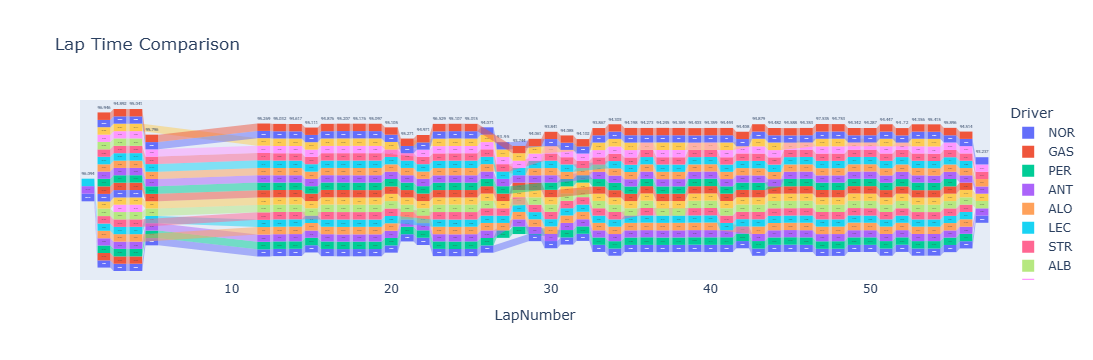

In [16]:
laps_clean = laps.pick_quicklaps().copy()
laps_clean['LapTime (s)'] = laps_clean['LapTime'].dt.total_seconds()

fig = px.funnel(
    laps_clean,
    x='LapNumber',
    y='LapTime (s)',
    color='Driver',
    title='Lap Time Comparison'
)

fig.show()

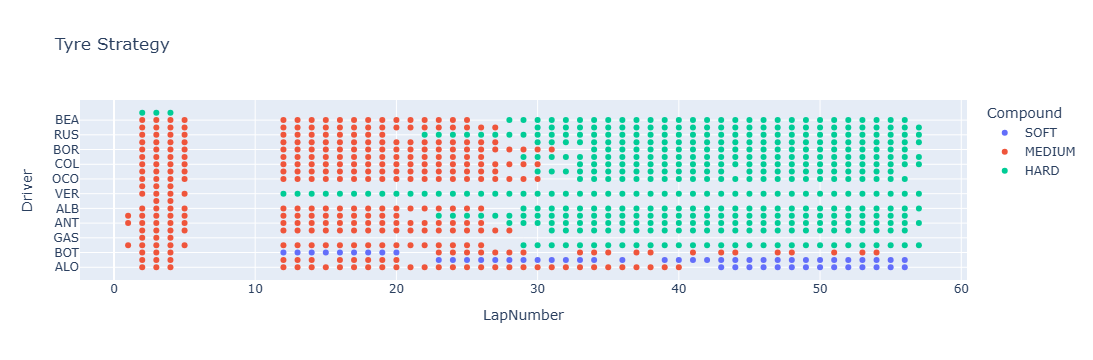

In [5]:
fig = px.scatter(
    laps_clean,
    x='LapNumber',
    y='Driver',
    color='Compound',
    title='Tyre Strategy',
    category_orders={"Compound": ["SOFT", "MEDIUM", "HARD"]}
)

fig.show()

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


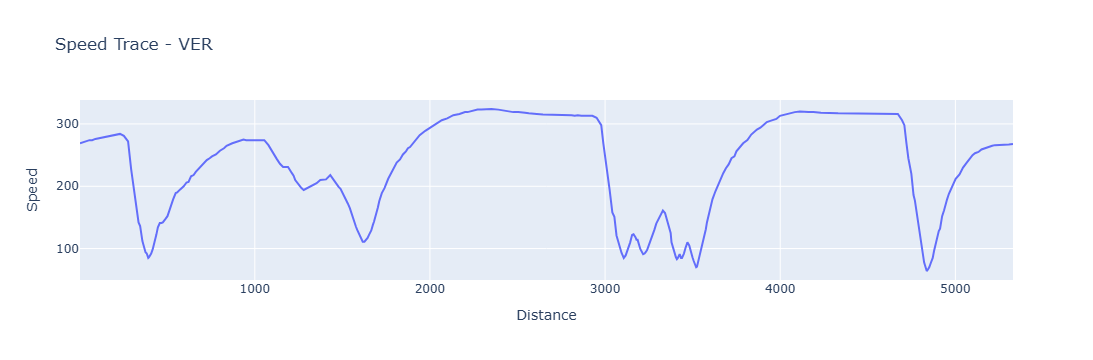

In [6]:
driver = 'VER'  # change driver
lap = session.laps.pick_driver(driver).pick_fastest()

car_data = lap.get_car_data().add_distance()

fig = px.line(
    car_data,
    x='Distance',
    y='Speed',
    title=f"Speed Trace - {driver}"
)

fig.show()

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


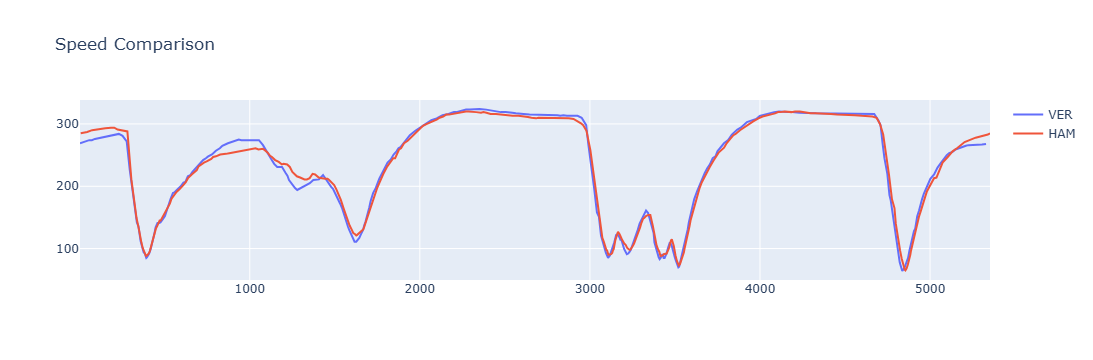

In [7]:
drivers = ['VER', 'HAM']

fig = go.Figure()

for drv in drivers:
    lap = session.laps.pick_driver(drv).pick_fastest()
    car_data = lap.get_car_data().add_distance()

    fig.add_trace(go.Scatter(
        x=car_data['Distance'],
        y=car_data['Speed'],
        name=drv
    ))

fig.update_layout(title='Speed Comparison')
fig.show()

In [8]:
# from dash import Dash, dcc, html

# app = Dash(__name__)

# app.layout = html.Div([
#     html.H1("F1 Dashboard"),
#     dcc.Graph(figure=fig)  # you can add multiple graphs here
# ])

# app.run(debug=True)

In [108]:
# !pip install dash

In [9]:
# c = session.session_info
# c

In [11]:
# session.

In [18]:
import fastf1

In [19]:
dir(fastf1)

['Cache',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '__version_short__',
 '__version_tuple__',
 '_api',
 '_version',
 'core',
 'ergast',
 'events',
 'exceptions',
 'get_event',
 'get_event_schedule',
 'get_events_remaining',
 'get_session',
 'get_testing_event',
 'get_testing_session',
 'internals',
 'livetiming',
 'logger',
 'mvapi',
 'req',
 'set_log_level',
 'utils',
 'warnings']